Učitavanje biblioteka

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm, laplace, poisson, binom, cauchy, gamma, beta, chi2, expon
from scipy.optimize import curve_fit

Učitavanje podataka

In [2]:
data = np.load('sunspot.npz')
B = data['B']
theta = np.degrees(data['inc'])
phi = np.degrees(data['az'])

# 1. Prvi zadatak

### 1.1 Mapa i histogram za jačinu magnetnog polja $B$

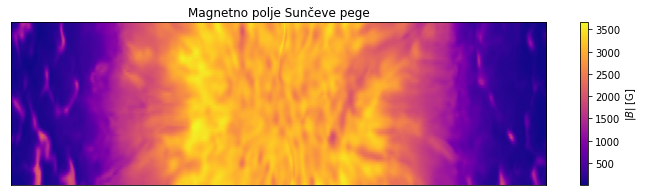

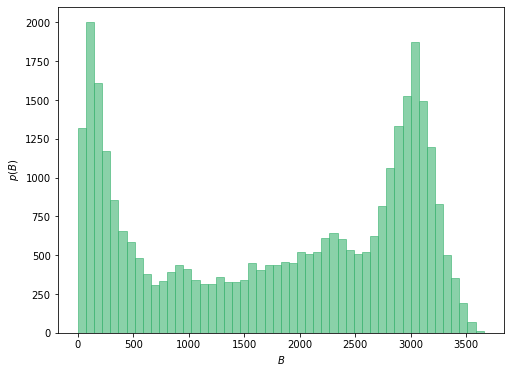

In [3]:
#Samo plotovanje stvari, flatten je da bi sve bio jedan niz
plt.figure(figsize=(12, 3))
im = plt.imshow(B, origin='lower', cmap='plasma', aspect='auto')
plt.colorbar(im, ax=plt.gca(), label=r'$|B|$ [G]')
plt.xticks([])
plt.yticks([])
plt.title('Magnetno polje Sunčeve pege')
plt.show()

plt.figure(figsize=(8, 6))
plt.xlabel(r'$B$')
plt.ylabel(r'$p(B)$')
plt.hist(B.flatten(), bins=50, color='mediumseagreen', alpha=0.6, edgecolor='mediumseagreen');

### 1.2 Mapa i histogram za inklinaciju $\theta$

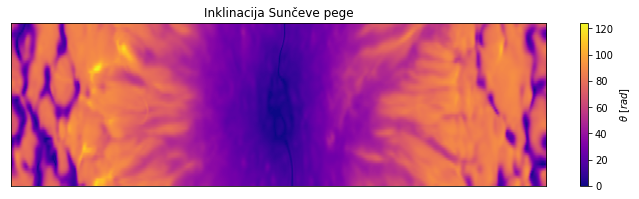

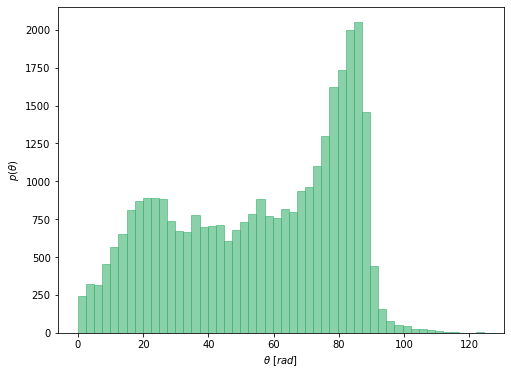

In [4]:
plt.figure(figsize=(12, 3))
im = plt.imshow(theta, origin='lower', cmap='plasma', aspect='auto')
plt.colorbar(im, ax=plt.gca(), label=r'$\theta \ [rad]$')
plt.xticks([])
plt.yticks([])
plt.title('Inklinacija Sunčeve pege')
plt.show()



plt.figure(figsize=(8, 6))
plt.xlabel(r'$\theta \ [rad]$')
plt.ylabel(r'$p(\theta) $')
plt.hist(theta.flatten(), bins=50, color='mediumseagreen', alpha=0.6, edgecolor='mediumseagreen');

### 1.3 Mapa i histogram za azimut $\varphi$

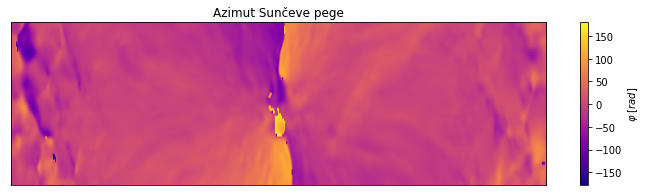

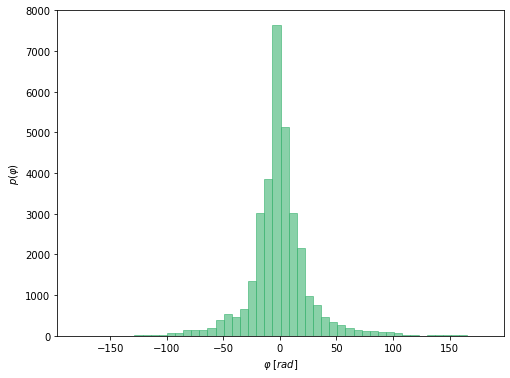

In [5]:
plt.figure(figsize=(12, 3))
im = plt.imshow(phi, origin='lower', cmap='plasma', aspect='auto')
plt.colorbar(im, ax=plt.gca(), label=r'$\varphi \ [rad]$')
plt.xticks([])
plt.yticks([])
plt.title('Azimut Sunčeve pege')
plt.show()

plt.figure(figsize=(8, 6))
plt.xlabel(r'$\varphi \ [rad]$')
plt.ylabel(r'$p(\varphi) $')
plt.hist(phi.flatten(), bins=50, color='mediumseagreen', alpha=0.6, edgecolor='mediumseagreen');

# 2. Drugi zadatak

### 2.1 Modelovanje azimuta $\varphi$ Laplasovom funkcijom

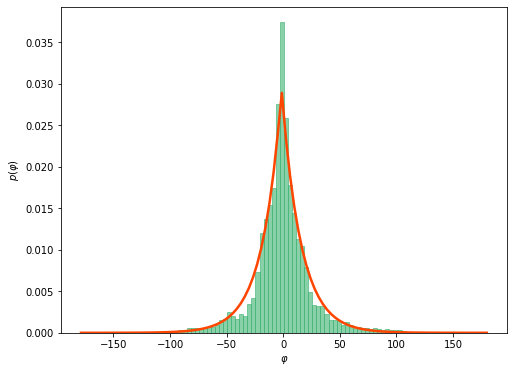

In [6]:
phi_flat = phi.flatten() #Sve se stavlja u jedan niz

plt.figure(figsize=(8, 6))
params = laplace.fit(phi_flat) #Traži parametre Laplasove funkcije koji najbolje opisuju raspodelu
x = np.linspace(min(phi_flat), max(phi_flat), 100) #Niz phi da bih posle lepo plotovala fit
pdf = laplace.pdf(x, *params) #Računa pdf za Laplasovu funkciju sa gore dobijenim parametrima za niz phi


#Plotovanje
plt.hist(phi_flat, bins=100, density=True,color='mediumseagreen', alpha=0.6, edgecolor='mediumseagreen')
plt.plot(x, pdf, color='orangered', linewidth=2.5)
plt.xlabel(r'$\varphi$')
plt.ylabel(r'$p(\varphi)$')
plt.show()

### 2.2 Modelovanje inklinacije $\theta$ kombinacijom normalne $\mathcal{{N}}$ i eksponencijalne raspodele $\mathrm{Exp}$

Ukupni model je dat kao:
$$
f(\theta) = w_{\mathrm{N}} \cdot \mathcal{{N}}(\mu, \sigma) + w_{\mathrm{E}} \cdot \mathrm{Exp} (\tau),
$$

dok mora da važi uslov:
$$w_{\mathrm{N}} + w_{\mathrm{E}} = 1$$

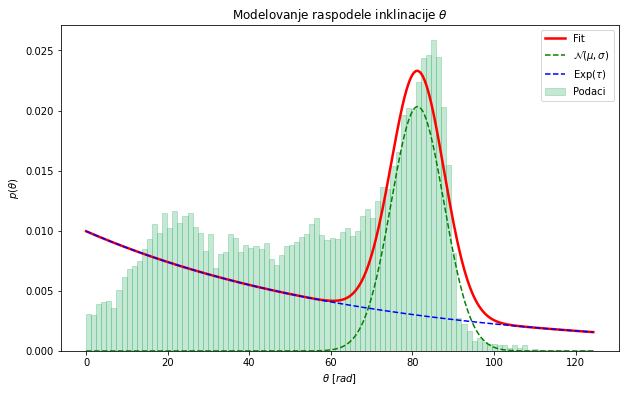

Parametri fita su:
$w_norm$ = 0.330, w_exp = 0.670
mu = 81.27
sigma = 6.47
tau = 67.26


In [7]:
theta = theta.flatten()

hist_theta, bins_theta = np.histogram(theta, bins=100, density=True) #Uzimamo vrednosti binova kako bismo posle mogli da ih fitujemo

# Tražimo gde je centar bina na x osi
x_theta = 0.5 * (bins_theta[:-1] + bins_theta[1:])

#Definišemo model koji je kombinacija normalne i esponencijalne raspodele
def theta_model(x, A_norm, A_exp, mu, sigma, tau):

    ukupno = A_norm + A_exp
    w_norm = A_norm / ukupno
    w_exp = A_exp / ukupno

    loc_exp = np.min(theta) #loc predstavlja šift levo desno, ovde biramo da počinje od najmanje vrednosti theta

    return (w_norm * norm.pdf(x, loc=mu, scale=sigma) +
            w_exp * expon.pdf(x, loc=loc_exp, scale=tau))

pocetne_vrednosti = [
    0.5,                  # A_norm
    0.5,                  # A_exp
    np.mean(theta),       # mu
    np.std(theta),        # sigma
    np.std(theta)         # tau
]

#Fitovanje
params, pcov = curve_fit(theta_model, x_theta, hist_theta, p0=pocetne_vrednosti)

A_norm, A_exp, mu, sigma, tau = params

# Sad na osnovu parametara možemo da izračunamotežine
w_norm = A_norm / (A_norm + A_exp)
w_exp = A_exp / (A_norm + A_exp)

#Plotovanje
x = np.linspace(np.min(theta), np.max(theta), 1000)

plt.figure(figsize=(10, 6))
plt.hist(theta, bins=100, density=True, color='mediumseagreen', alpha=0.3, edgecolor='mediumseagreen', label='Podaci')
plt.plot(x, theta_model(x, *params), 'r-', lw=2.5, label='Fit')
plt.plot(x, w_norm * norm.pdf(x, mu, sigma), 'g--', label=r'$\mathcal{{N}}(\mu, \sigma)$')
plt.plot(x, w_exp * expon.pdf(x, loc=np.min(theta), scale=tau), 'b--', label=r'$\mathrm{Exp} (\tau)$')

plt.xlabel(r'$\theta \ [rad]$')
plt.ylabel(r'$p(\theta) $')
plt.title(r'Modelovanje raspodele inklinacije $\theta$')
plt.legend()

plt.show()

print("Parametri fita su:")
print(f"$w_norm$ = {w_norm:.3f}, w_exp = {w_exp:.3f}")
print(f"mu = {mu:.2f}")
print(f"sigma = {sigma:.2f}")
print(f"tau = {tau:.2f}")

### 2.3 Modelovanje jačine magnetnog polja $B$ kombinacijom normalne, eksponencijalne i uniformne raspodele

$$
f(B) = w_{\mathrm{N}} \cdot \mathcal{{N}}(\mu, \sigma) + w_{\mathrm{E}} \cdot \mathrm{Exp} (\tau) + w_{\mathrm{U}} \cdot \frac{1}{B_{\max} - B_{\min}},
$$

dok mora da važi uslov:
$$w_{\mathrm{N}} + w_{\mathrm{E}} + w_{\mathrm{U}} = 1$$


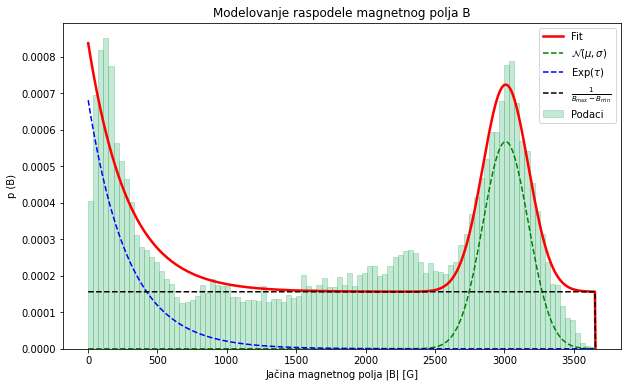

Težine:
w_normal = 0.233
w_expon  = 0.195
w_uniform= 0.572

Parametri:
mu = 3010.09, sigma = 163.89
tau = 286.36


In [8]:
B = B.flatten()

hist_B, bins_B = np.histogram(B, bins=100, density=True)
x_B = 0.5 * (bins_B[:-1] + bins_B[1:])


def B_model(x, A_n, A_e, A_u, mu, sigma, tau):

    ukupno = A_n + A_e + A_u

    w_n = A_n / ukupno
    w_e = A_e / ukupno
    w_u = A_u / ukupno

    normal_part = norm.pdf(x, loc=mu, scale=sigma)

    expon_part = expon.pdf(x, loc=np.min(B), scale=tau)

    uniform_part = uniform.pdf(x, loc=np.min(B), scale=(np.max(B) - np.min(B)))

    return w_n * normal_part + w_e * expon_part + w_u * uniform_part


pocetni_parametri = [
    0.4,  # A_n
    0.4,  # A_e
    0.2,  # A_u
    np.mean(B),
    np.std(B),
    np.std(B)
]

params, pcov = curve_fit(B_model, x_B, hist_B, p0=pocetni_parametri, maxfev=10000)

A_n, A_e, A_u, mu, sigma, tau = params


total = A_n + A_e + A_u
w_n = A_n / total
w_e = A_e / total
w_u = A_u / total



x = np.linspace(np.min(B), np.max(B), 1000)

plt.figure(figsize=(10, 6))
plt.hist(B, bins=100, density=True, color='mediumseagreen', alpha=0.3, edgecolor='mediumseagreen', label='Podaci')
plt.plot(x, B_model(x, *params), 'r-', lw=2.5, label='Fit')
plt.plot(x, w_n * norm.pdf(x, mu, sigma), 'g--', label=r'$\mathcal{{N}}(\mu, \sigma)$')
plt.plot(x, w_e * expon.pdf(x, loc=np.min(B), scale=tau), 'b--', label=r'$\mathrm{Exp} (\tau)$')
plt.plot(x, w_u * uniform.pdf(x, loc= np.min(B), scale= np.max(B) -np.min(B)), 'k--', label=r'$\frac{1}{B_{\max} - B_{\min}}$')
plt.xlabel('Jačina magnetnog polja |B| [G]')
plt.ylabel('p (B)')
plt.title('Modelovanje raspodele magnetnog polja B')
plt.legend()

plt.show()



print("Težine:")
print(f"w_normal = {w_n:.3f}")
print(f"w_expon  = {w_e:.3f}")
print(f"w_uniform= {w_u:.3f}")

print("\nParametri:")
print(f"mu = {mu:.2f}, sigma = {sigma:.2f}")
print(f"tau = {tau:.2f}")

# 3. Treći zadatak

### 3.1 Jačina magnetnog polja $B$

In [9]:
mean = np.mean(B)
median = np.median(B)
std = np.std(B)
q75, q25 = np.percentile(B, [75, 25])
sigma_q = q75 - q25

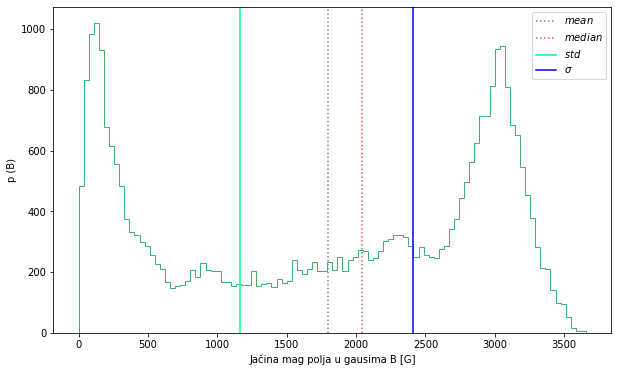

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(B.flatten(), bins=100,  histtype='step', color='mediumseagreen');
plt.axvline(mean, color='grey', linestyle=':', label=r'$mean$')
plt.axvline(median, color='indianred', linestyle=':', label=r'$median$')
plt.axvline(std, label=r'$std$', color='springgreen')
plt.axvline(sigma_q, label=r'$\sigma$', color='blue')
plt.legend()
plt.xlabel('Jačina mag polja u gausima B [G]')
plt.ylabel('p (B)')
plt.show()

### 3.2 Azimut $\varphi$

In [11]:
mean = np.mean(phi)
median = np.median(phi)
std = np.std(phi)
q75, q25 = np.percentile(phi, [75, 25])
sigma_q = q75 - q25

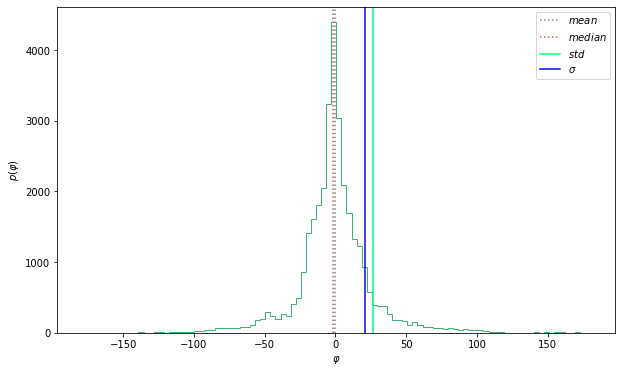

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(phi.flatten(), bins=100,  histtype='step', color='mediumseagreen')
plt.axvline(mean, color='grey', linestyle=':', label=r'$mean$')
plt.axvline(median, color='indianred', linestyle=':', label=r'$median$')
plt.axvline(std, label=r'$std$', color='springgreen')
plt.axvline(sigma_q, label=r'$\sigma$', color='blue')
plt.legend()
plt.xlabel(r'$\varphi$')
plt.ylabel(r'$p (\varphi)$')
plt.show()

### 3.3 Inklinacija $\theta$

In [13]:
mean = np.mean(theta)
median = np.median(theta)
std = np.std(theta)
q75, q25 = np.percentile(theta, [75, 25])
sigma_q = q75 - q25

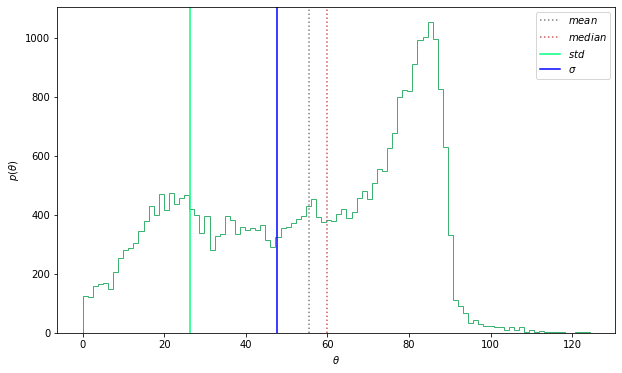

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(theta.flatten(), bins=100,  histtype='step', color='mediumseagreen')
plt.axvline(mean, color='grey', linestyle=':', label=r'$mean$')
plt.axvline(median, color='indianred', linestyle=':', label=r'$median$')
plt.axvline(std, label=r'$std$', color='springgreen')
plt.axvline(sigma_q, label=r'$\sigma$', color='blue')
plt.legend()
plt.xlabel(r'$\theta$')
plt.ylabel(r'$p (\theta)$')
plt.show()

Robusnost deskriptivnih statistika procenjena je analizom srednje vrednosti, medijane, standardne devijacije i $\sigma_G$ za parametre $B$, $\theta$ i $\varphi$. Vidimo da statistike poput srednje vrednosti i standardne devijacije nisu robusne na prisustvo asimetrije i ekstremnih vrednosti, dok su medijana i $\sigma_G$ stabilnije mere centralne tendencije i disperzije.

Raspodela inklinacije $\theta$ pokazuje izraženu asimetriju i prisustvo repa ka većim vrednostima. U takvom slučaju srednja vrednost je pomerena u odnosu na medijanu, što ukazuje na uticaj ekstremnih vrednosti. Standardna devijacija je takođe povećana zbog širokog repa raspodele, dok je $\sigma_G$ stabilniji i bolje opisuje centralni deo raspodele. Ovo ukazuje da su medijana i $\sigma_G$ robusnije mere za ovaj parametar.

Raspodela magnetnog polja $B$ je složena. Zbog toga srednja vrednost može biti značajno pod uticajem ekstremnih vrednosti, dok standardna devijacija precenjuje rasipanje podataka. Medijana i interkvartilni raspon pokazuju veću stabilnost i pružaju pouzdaniji opis tipičnih vrednosti u prisustvu kompleksne raspodele.

Raspodela azimuta $\varphi$ je približno simetrična i dobro opisana Laplasovom raspodelom. U ovom slučaju srednja vrednost i medijana su približno jednake, što ukazuje na odsustvo značajne asimetrije. Standardna devijacija daje dobru meru rasipanja, ali i dalje ostaje osetljiva na potencijalne ekstremne vrednosti.

# 4. Zadatak

Proveravamo važenje centralne granične teoreme

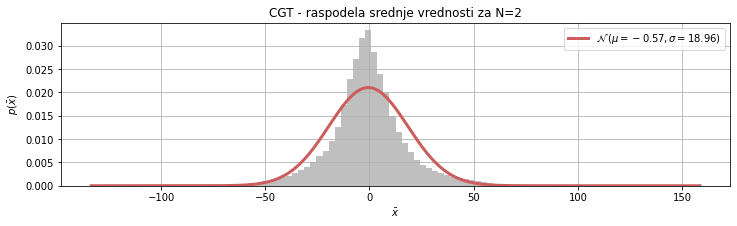

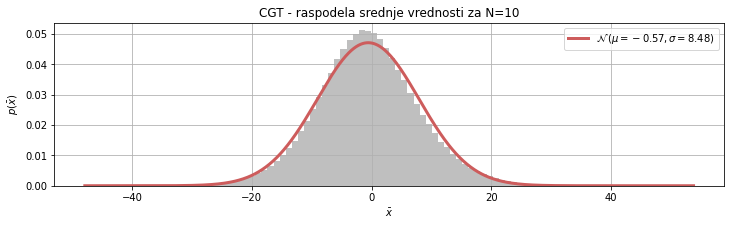

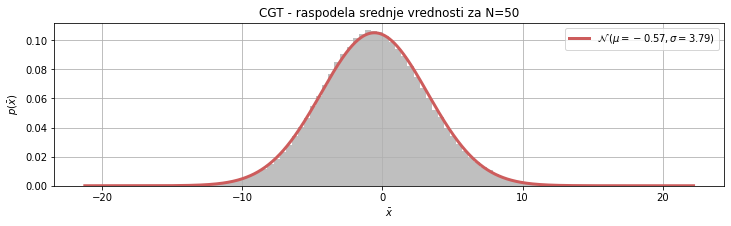

In [15]:
N = [2, 10, 50]
M = int(1e6)

p = phi.flatten()

xl = np.random.choice(p, size=(max(N), M), replace=True)

for i in range(len(N)):
    x_i = xl[:N[i], :].mean(axis=0)
    plt.figure(figsize=(12, 3))
    plt.hist(x_i,bins=100,histtype='stepfilled',density=True,color='grey',alpha=0.5)
    mu = np.mean(p)
    sigma = np.std(p) / np.sqrt(N[i])
    dist = norm(mu, sigma)
    x_pdf = np.linspace(np.min(x_i), np.max(x_i), 1000)
    plt.plot(x_pdf,dist.pdf(x_pdf),color='indianred',lw=3,label=rf'$\mathcal{{N}}\,(\mu={mu:.2f}, \sigma={sigma:.2f})$')
    plt.xlabel(r'$\bar{x}$')
    plt.ylabel(r'$p(\bar{x})$')
    plt.title(rf'CGT - raspodela srednje vrednosti za N={N[i]}')
    plt.legend()
    plt.grid()
    plt.show()

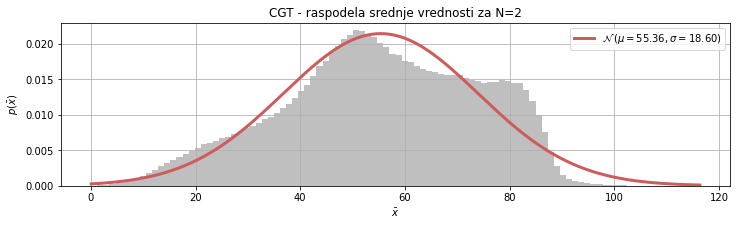

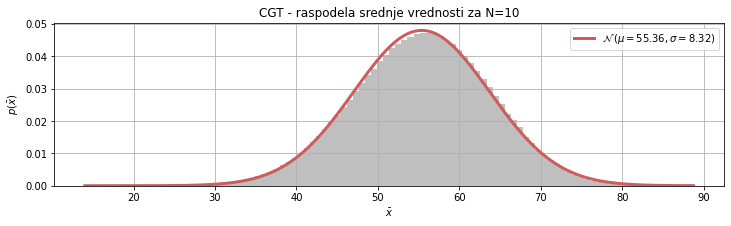

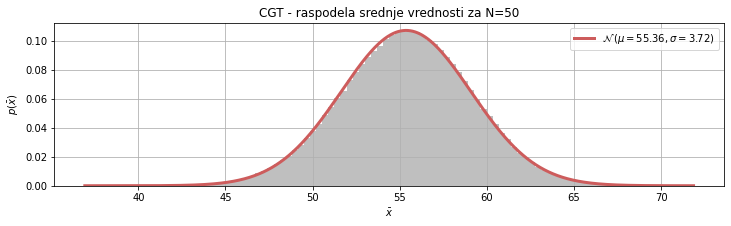

In [16]:
N = [2, 10, 50]
M = int(1e6)

p = theta.flatten()

xl = np.random.choice(p, size=(max(N), M), replace=True)

for i in range(len(N)):
    x_i = xl[:N[i], :].mean(axis=0)
    plt.figure(figsize=(12, 3))
    plt.hist(x_i,bins=100,histtype='stepfilled',density=True,color='grey',alpha=0.5)
    mu = np.mean(p)
    sigma = np.std(p) / np.sqrt(N[i])
    dist = norm(mu, sigma)
    x_pdf = np.linspace(np.min(x_i), np.max(x_i), 1000)
    plt.plot(x_pdf,dist.pdf(x_pdf),color='indianred',lw=3,label=rf'$\mathcal{{N}}\,(\mu={mu:.2f}, \sigma={sigma:.2f})$')
    plt.xlabel(r'$\bar{x}$')
    plt.ylabel(r'$p(\bar{x})$')
    plt.title(rf'CGT - raspodela srednje vrednosti za N={N[i]}')
    plt.legend()
    plt.grid()
    plt.show()


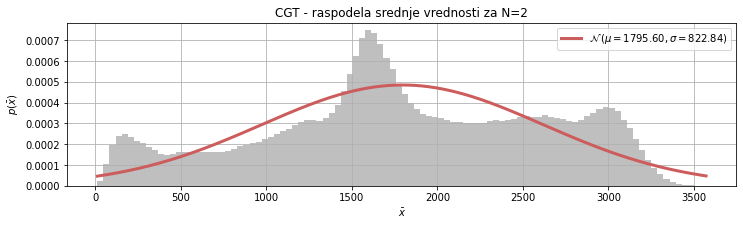

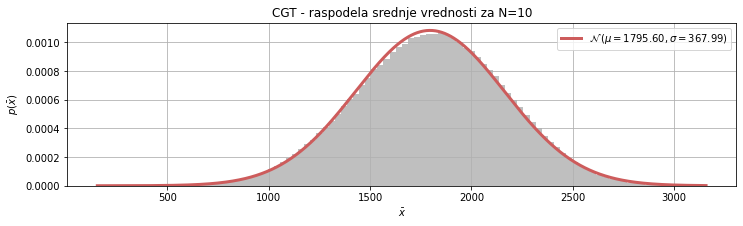

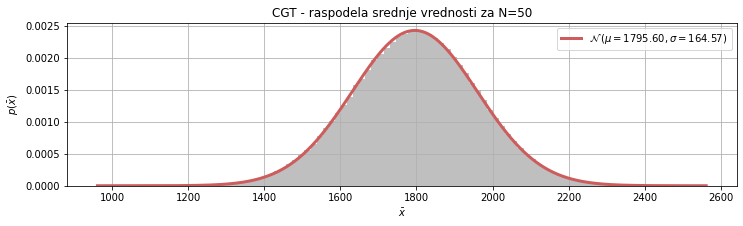

In [17]:
N = [2, 10, 50]
M = int(1e6)

p = B.flatten()

xl = np.random.choice(p, size=(max(N), M), replace=True)

for i in range(len(N)):
    x_i = xl[:N[i], :].mean(axis=0)
    plt.figure(figsize=(12, 3))
    plt.hist(x_i,bins=100,histtype='stepfilled',density=True,color='grey',alpha=0.5)
    mu = np.mean(p)
    sigma = np.std(p) / np.sqrt(N[i])
    dist = norm(mu, sigma)
    x_pdf = np.linspace(np.min(x_i), np.max(x_i), 1000)
    plt.plot(x_pdf,dist.pdf(x_pdf),color='indianred',lw=3,label=rf'$\mathcal{{N}}\,(\mu={mu:.2f}, \sigma={sigma:.2f})$')
    plt.xlabel(r'$\bar{x}$')
    plt.ylabel(r'$p(\bar{x})$')
    plt.title(rf'CGT - raspodela srednje vrednosti za N={N[i]}')
    plt.legend()
    plt.grid()
    plt.show()


Vidimo da važi centralna granična teorema u svim slučajevima.

# 5. Peti zadatak

In [18]:
mu0=4*np.pi*1e-7 #H/m
B1= B * 1e-4 #Prebacujemo iz G u T

P= B1**2 / (2*mu0)

s_B = np.std(B1,ddof=1)

B_srednje = np.mean(B1)
dP_dB = B_srednje / mu0
s_P_propagacija = s_B * abs(dP_dB)
s_P_direktno = np.std(P,ddof=1)

apsolutno_odstupanje = abs(s_P_propagacija - s_P_direktno)
relativno_odstupanje = apsolutno_odstupanje / s_P_direktno 

In [19]:
print("s_P propagacijom =", s_P_propagacija)
print("s_P direktno iz P =", s_P_direktno)
print("Apsolutno odstupanje =", apsolutno_odstupanje)
print("Relativno odstupanje =", relativno_odstupanje)

s_P propagacijom = 16627.889580775427
s_P direktno iz P = 15740.621
Apsolutno odstupanje = 887.268487025427
Relativno odstupanje = 0.05636807351761536
